# Multivariate Linear Regression - AQ-10 Autism Screening Result

**Goal:** predict someone's AQ-10 result using easy-to-get info (age, family history of autism, country, jaundice at birth) instead of the full 10-question test. Could help with quick screening where the full assessment isn't easy to get.

Data: three merged datasets (Adult, Child, Adolescent) from the UCI ML Repository, by Fadi Thabtah.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib

SEQ_BLUE = "#2a78d6"

## Step 1 - Load and merge

In [18]:
adult = pd.read_csv('Autism_Adult_Data.csv')
adult['age_group'] = 'adult'

child = pd.read_csv('Autism_Child_Data.csv')
child['age_group'] = 'child'

adolescent = pd.read_csv('Autism_Adolescent_Data.csv')
adolescent['age_group'] = 'adolescent'

df = pd.concat([adult, child, adolescent], ignore_index=True)

print(df.shape)
df.info()

(1100, 23)
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1100 non-null   int64 
 1   A1_Score         1100 non-null   int64 
 2   A2_Score         1100 non-null   int64 
 3   A3_Score         1100 non-null   int64 
 4   A4_Score         1100 non-null   int64 
 5   A5_Score         1100 non-null   int64 
 6   A6_Score         1100 non-null   int64 
 7   A7_Score         1100 non-null   int64 
 8   A8_Score         1100 non-null   int64 
 9   A9_Score         1100 non-null   int64 
 10  A10_Score        1100 non-null   int64 
 11  age              1100 non-null   object
 12  gender           1100 non-null   str   
 13  ethnicity        1100 non-null   str   
 14  jundice          1100 non-null   str   
 15  austim           1100 non-null   str   
 16  contry_of_res    1100 non-null   str   
 17  used_app_before  1100 non-null   

## Step 2 - Clean

In [19]:
df = df.drop(columns=['id', 'Class/ASD'])

df['ethnicity'] = df['ethnicity'].replace('?', 'Unknown')
df['relation'] = df['relation'].replace('?', 'Unknown')

# age arrives as a mix of str/int across the 3 source files and has a
# handful of '?' placeholders (adult + child); coerce to numeric and
# drop the few rows that can't be parsed.
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print('rows dropped for unparseable age:', df['age'].isna().sum())
df = df.dropna(subset=['age'])

# one adult-data row records age=383 (data-entry error, not a real human
# age) which skews the age-vs-result relationship explored in Step 7.
print('rows dropped for implausible age (>120):', (df['age'] > 120).sum())
df = df[df['age'] <= 120].reset_index(drop=True)

df.shape

rows dropped for unparseable age: 6
rows dropped for implausible age (>120): 1


(1093, 21)

In [20]:
a_score_cols = [f'A{i}_Score' for i in range(1, 11)]
df = df.drop(columns=a_score_cols)
df.shape

(1093, 11)

### Why I dropped A1-A10

`result` is just the sum of the `A1_Score`-`A10_Score` answers, so keeping them would let the model cheat by adding them up instead of actually predicting anything. Also dropped `Class/ASD` (just a cutoff on `result`) and `id` (not useful for prediction).

## Step 3 - Exploratory Data Analysis

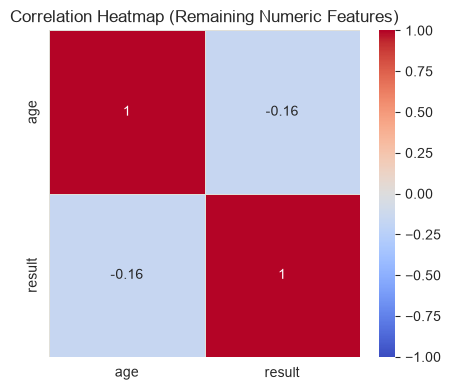

In [21]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(4.5, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#e1e0d9')
plt.title('Correlation Heatmap (Remaining Numeric Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

**What this shows:** `age` and `result` are the only numeric columns right now (everything else gets encoded in Step 4). They have a weak negative correlation (about -0.16) - older people score a little lower, but age alone doesn't explain much.

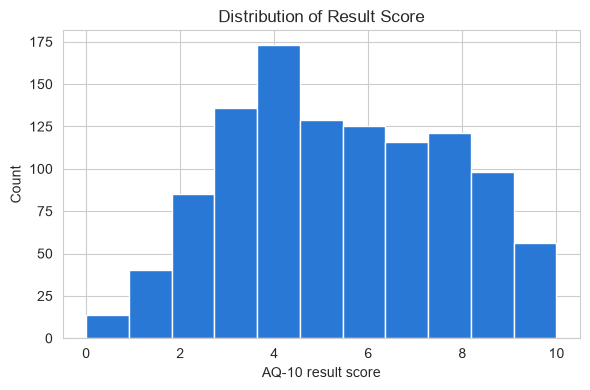

In [22]:
plt.figure(figsize=(6, 4))
df['result'].plot(kind='hist', bins=11, color=SEQ_BLUE, edgecolor='white')
plt.xlabel('AQ-10 result score')
plt.ylabel('Count')
plt.title('Distribution of Result Score')
plt.tight_layout()
plt.savefig('result_histogram.png', dpi=150)
plt.show()

**What this shows:** `result` scores are spread fairly evenly across 0-10 (mean about 5.4), not bunched up at the low end like you'd expect in a random population. Makes sense since this is a screening dataset, not a random sample.

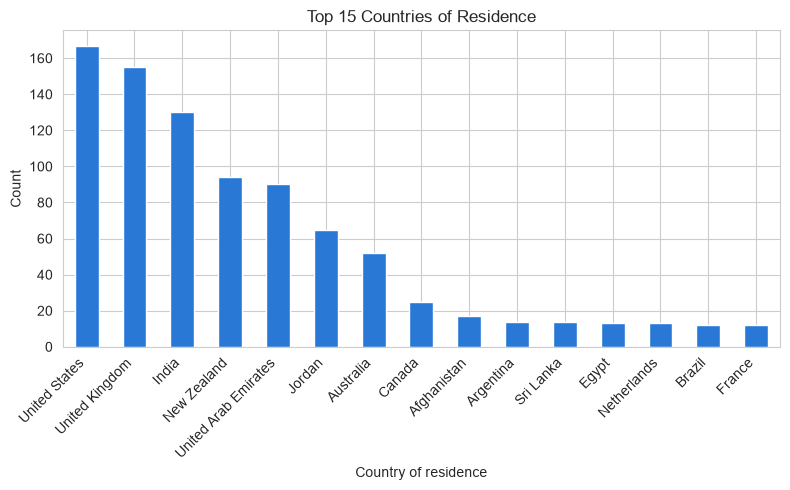

In [23]:
top_countries = df['contry_of_res'].value_counts().head(15)
plt.figure(figsize=(8, 5))
top_countries.plot(kind='bar', color=SEQ_BLUE)
plt.ylabel('Count')
plt.xlabel('Country of residence')
plt.title('Top 15 Countries of Residence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('country_distribution.png', dpi=150)
plt.show()

**What this shows:** there are 89 countries, but most rows come from just a few - US, UK, and India alone make up about 40% of the data. The model will see way more examples from these countries than from the rest.

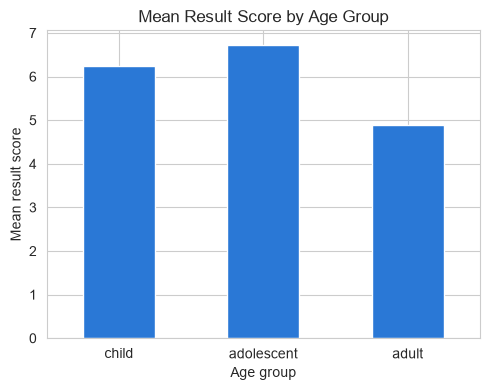

In [24]:
group_order = ['child', 'adolescent', 'adult']
mean_by_group = df.groupby('age_group')['result'].mean().reindex(group_order)
plt.figure(figsize=(5, 4))
mean_by_group.plot(kind='bar', color=SEQ_BLUE)
plt.ylabel('Mean result score')
plt.xlabel('Age group')
plt.title('Mean Result Score by Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('result_by_age_group.png', dpi=150)
plt.show()

**What this shows:** average `result` is highest for adolescents (~6.7), then children (~6.3), then adults (~4.9). Adults tend to score lower, which is a useful signal for the model even without any behavioral answers.

## Step 4 - Feature engineering

In [25]:
encode_cols = ['gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res',
               'used_app_before', 'relation', 'age_group', 'age_desc']

encoders = {}
for col in encode_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = ['age', 'gender', 'ethnicity', 'jundice', 'austim',
                'contry_of_res', 'used_app_before', 'relation', 'age_group']
target_col = 'result'

X = df[feature_cols]
y = df[target_col]
X.head()

,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,relation,age_group
0,26.0,0,10,0,0,86,0,4,1
1,24.0,1,3,0,1,17,0,4,1
2,27.0,1,3,1,1,76,0,2,1
3,35.0,0,10,0,1,86,0,4,1
4,40.0,0,9,0,0,29,0,5,1


## Step 5 - Split and scale

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((874, 9), (219, 9))

## Step 6 - Train and compare 4 models

In [27]:
sgd = SGDRegressor(random_state=42)
n_epochs = 200
sgd_train_mse = []
sgd_test_mse = []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    sgd_train_mse.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    sgd_test_mse.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

print(f'SGDRegressor MSE: {sgd_test_mse[-1]:.4f}')

SGDRegressor MSE: 6.3162


In [28]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_reg_mse = mean_squared_error(y_test, lin_reg.predict(X_test_scaled))
print(f'LinearRegression MSE: {lin_reg_mse:.4f}')

LinearRegression MSE: 6.3069


In [29]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_scaled, y_train)
tree_reg_mse = mean_squared_error(y_test, tree_reg.predict(X_test_scaled))
print(f'DecisionTreeRegressor MSE: {tree_reg_mse:.4f}')

DecisionTreeRegressor MSE: 9.4572


In [30]:
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_scaled, y_train)
forest_reg_mse = mean_squared_error(y_test, forest_reg.predict(X_test_scaled))
print(f'RandomForestRegressor MSE: {forest_reg_mse:.4f}')

RandomForestRegressor MSE: 5.9047


## Step 7 - Plots

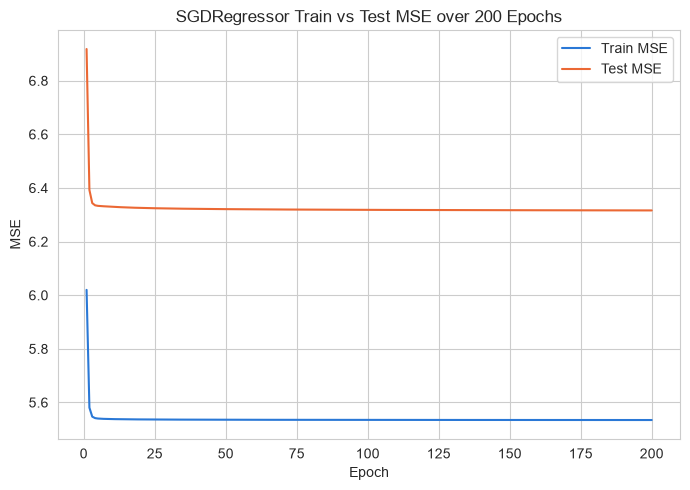

In [31]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, n_epochs + 1), sgd_train_mse, label='Train MSE', color=SEQ_BLUE)
plt.plot(range(1, n_epochs + 1), sgd_test_mse, label='Test MSE', color='#eb6834')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('SGDRegressor Train vs Test MSE over 200 Epochs')
plt.legend()
plt.tight_layout()
plt.savefig('sgd_loss_curve.png', dpi=150)
plt.show()

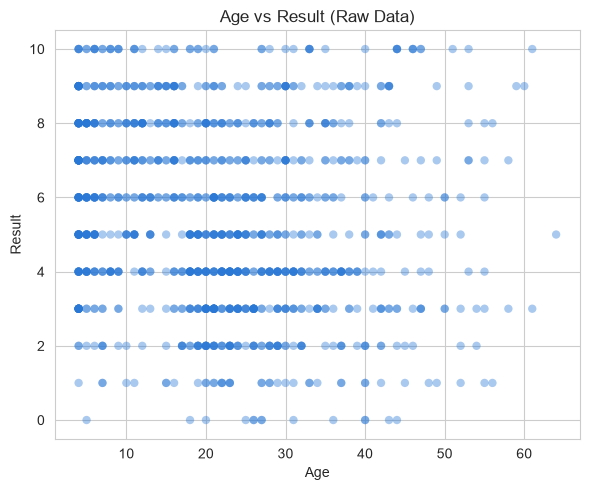

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(df['age'], df['result'], alpha=0.4, color=SEQ_BLUE, edgecolor='none')
plt.xlabel('Age')
plt.ylabel('Result')
plt.title('Age vs Result (Raw Data)')
plt.tight_layout()
plt.savefig('age_vs_result_before.png', dpi=150)
plt.show()

C:\Users\divin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


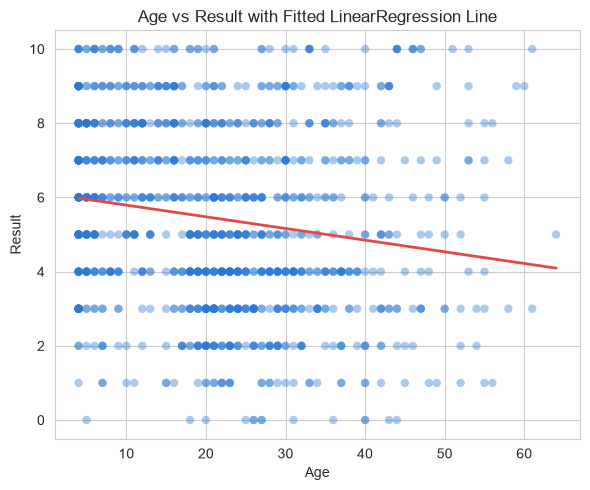

In [33]:
age_only = df[['age']]
age_reg = LinearRegression()
age_reg.fit(age_only, y)
age_line_x = np.linspace(df['age'].min(), df['age'].max(), 100).reshape(-1, 1)
age_line_y = age_reg.predict(age_line_x)

plt.figure(figsize=(6, 5))
plt.scatter(df['age'], df['result'], alpha=0.4, color=SEQ_BLUE, edgecolor='none')
plt.plot(age_line_x, age_line_y, color='#e34948', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Result')
plt.title('Age vs Result with Fitted LinearRegression Line')
plt.tight_layout()
plt.savefig('age_vs_result_after.png', dpi=150)
plt.show()

## Step 8 - Save best model

In [34]:
model_mse = {
    'SGDRegressor': sgd_test_mse[-1],
    'LinearRegression': lin_reg_mse,
    'DecisionTreeRegressor': tree_reg_mse,
    'RandomForestRegressor': forest_reg_mse,
}
models = {
    'SGDRegressor': sgd,
    'LinearRegression': lin_reg,
    'DecisionTreeRegressor': tree_reg,
    'RandomForestRegressor': forest_reg,
}

best_name = min(model_mse, key=model_mse.get)
best_model = models[best_name]
print(f'Best model: {best_name} (test MSE = {model_mse[best_name]:.4f})')

joblib.dump(best_model, '../API/best_model.pkl')
joblib.dump(scaler, '../API/scaler.pkl')

Best model: RandomForestRegressor (test MSE = 5.9047)


['../API/scaler.pkl']